# CSI To Pose Experiment

Purpose: visualize the Milestone 10 research path from a processed CSI feature map to a pose-style keypoint heatmap and per-keypoint confidence scores.

Run path: `uv sync --extra research`, then open this notebook with `uv run jupyter lab notebooks` and run all cells. The notebook intentionally avoids requiring torch.

Fixture / simulated source: deterministic synthetic CSI made from sinusoidal body-motion ridges and subcarrier-localized reflection peaks.

Expected interpretation: the CSI map should show a moving reflection band; the fallback pose helper should place keypoints inside the normalized image plane and assign higher confidence to joints supported by stronger synthetic energy.

Limitations: this is a research-only diagnostic. It does not load trained DensePose weights, does not prove Rust parity, and does not perform production inference.


In [1]:
import importlib

import matplotlib.pyplot as plt
import numpy as np

try:
    ruview_nn = importlib.import_module("ruview.nn")
    torch_available = importlib.util.find_spec("torch") is not None
    backend_note = f"ruview.nn import ok; torch available: {torch_available}"
except Exception as exc:
    ruview_nn = None
    torch_available = False
    backend_note = f"Fallback NumPy path: {type(exc).__name__}: {exc}"

print(backend_note)


ruview.nn import ok; torch available: False


In [2]:
KEYPOINT_NAMES = [
    "nose",
    "left_eye",
    "right_eye",
    "left_ear",
    "right_ear",
    "left_shoulder",
    "right_shoulder",
    "left_elbow",
    "right_elbow",
    "left_wrist",
    "right_wrist",
    "left_hip",
    "right_hip",
    "left_knee",
    "right_knee",
    "left_ankle",
    "right_ankle",
]


def synthetic_csi_feature_map(n_frames=72, n_subcarriers=56):
    time = np.linspace(0.0, 1.0, n_frames)
    subcarrier = np.linspace(-1.0, 1.0, n_subcarriers)
    tt, ss = np.meshgrid(time, subcarrier, indexing="ij")

    torso_track = 0.28 * np.sin(2.0 * np.pi * (tt + 0.08))
    torso = 1.25 * np.exp(-((ss - torso_track) ** 2) / (2.0 * 0.085**2))
    limb_track = -0.35 * np.cos(2.0 * np.pi * (1.7 * tt + 0.11))
    limb = 0.72 * np.exp(-((ss - limb_track) ** 2) / (2.0 * 0.12**2))
    breathing = 0.18 * np.sin(2.0 * np.pi * 4.0 * tt)
    static_room = 0.16 * np.cos(2.0 * np.pi * (2.0 * ss + 0.25))

    feature = torso + limb + breathing + static_room
    feature = (feature - feature.min()) / (feature.max() - feature.min())
    return time, subcarrier, feature


def fallback_csi_to_pose(feature, n_keypoints=17, heatmap_size=56):
    energy = np.maximum(feature - feature.min(), 0.0)
    time_profile = energy.mean(axis=1) + 1e-9
    subcarrier_profile = energy.mean(axis=0) + 1e-9
    motion_center = np.average(np.linspace(0.0, 1.0, feature.shape[0]), weights=time_profile)
    lateral_center = np.average(np.linspace(-1.0, 1.0, feature.shape[1]), weights=subcarrier_profile)

    joint_phase = np.linspace(0.0, 2.0 * np.pi, n_keypoints, endpoint=False)
    y_base = np.linspace(0.16, 0.88, n_keypoints)
    x = 0.50 + 0.18 * np.sin(joint_phase + lateral_center * np.pi / 2.0)
    y = y_base + 0.035 * np.cos(2.0 * joint_phase + motion_center * np.pi)
    keypoints = np.column_stack([np.clip(x, 0.05, 0.95), np.clip(y, 0.05, 0.95)])

    confidence = 0.45 + 0.45 * (0.5 + 0.5 * np.sin(joint_phase + feature.std() * np.pi))
    confidence *= 0.85 + 0.15 * (energy.max(axis=1).mean() / energy.max())
    confidence = np.clip(confidence, 0.05, 0.98)

    yy, xx = np.mgrid[0:heatmap_size, 0:heatmap_size]
    heatmaps = []
    for (kx, ky), score in zip(keypoints, confidence):
        px = kx * (heatmap_size - 1)
        py = ky * (heatmap_size - 1)
        sigma = 1.7 + (1.0 - score) * 2.0
        heatmaps.append(score * np.exp(-((xx - px) ** 2 + (yy - py) ** 2) / (2.0 * sigma**2)))

    keypoint_heatmap = np.max(np.stack(heatmaps), axis=0)
    return keypoints, confidence, keypoint_heatmap


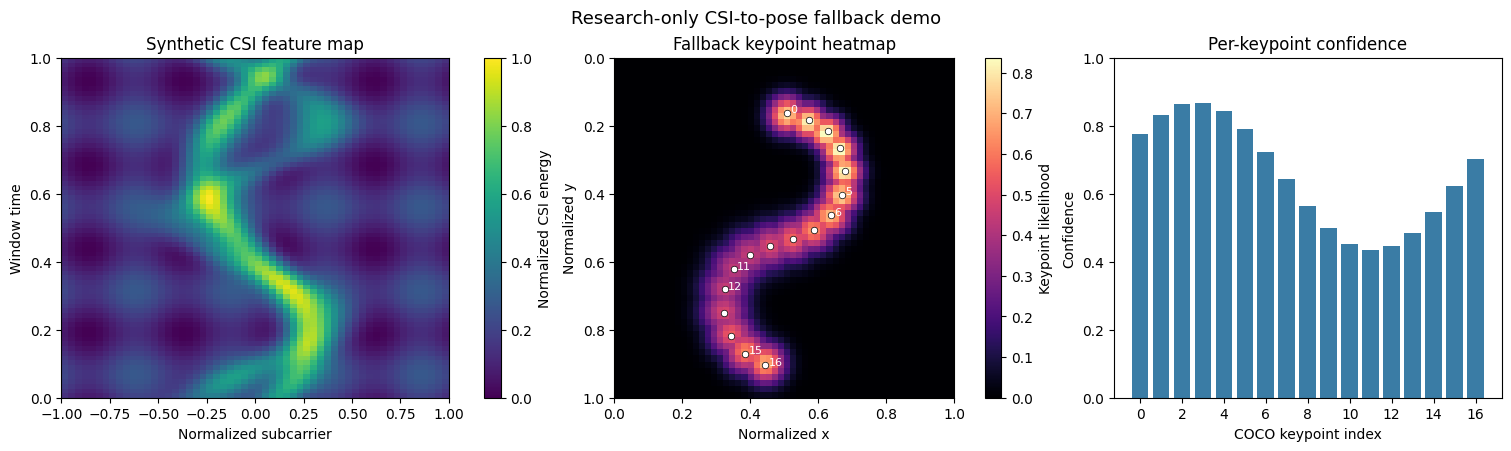

In [3]:
time_axis, subcarrier_axis, csi_feature = synthetic_csi_feature_map()
keypoints, confidence, keypoint_heatmap = fallback_csi_to_pose(csi_feature)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), constrained_layout=True)

im0 = axes[0].imshow(
    csi_feature,
    aspect="auto",
    origin="lower",
    extent=[subcarrier_axis.min(), subcarrier_axis.max(), time_axis.min(), time_axis.max()],
    cmap="viridis",
)
axes[0].set_title("Synthetic CSI feature map")
axes[0].set_xlabel("Normalized subcarrier")
axes[0].set_ylabel("Window time")
fig.colorbar(im0, ax=axes[0], label="Normalized CSI energy")

im1 = axes[1].imshow(
    keypoint_heatmap,
    aspect="equal",
    origin="upper",
    extent=[0.0, 1.0, 1.0, 0.0],
    cmap="magma",
)
axes[1].scatter(keypoints[:, 0], keypoints[:, 1], c="white", s=22, edgecolor="black", linewidth=0.5)
for idx in [0, 5, 6, 11, 12, 15, 16]:
    axes[1].text(keypoints[idx, 0] + 0.01, keypoints[idx, 1], str(idx), color="white", fontsize=8)
axes[1].set_title("Fallback keypoint heatmap")
axes[1].set_xlabel("Normalized x")
axes[1].set_ylabel("Normalized y")
fig.colorbar(im1, ax=axes[1], label="Keypoint likelihood")

axes[2].bar(np.arange(len(confidence)), confidence, color="#3a7ca5")
axes[2].set_ylim(0.0, 1.0)
axes[2].set_title("Per-keypoint confidence")
axes[2].set_xlabel("COCO keypoint index")
axes[2].set_ylabel("Confidence")
axes[2].set_xticks(np.arange(0, len(confidence), 2))

fig.suptitle("Research-only CSI-to-pose fallback demo", fontsize=13)
plt.show()


Expected interpretation: the brightest CSI ridge drives the rough body center, while the confidence bars vary smoothly with deterministic synthetic energy. When real `ruview.nn` helpers land, this notebook can swap the fallback helper for guarded calls into those modules.

Limitations: no trained checkpoint, no MM-Fi ground truth, no DensePose UV regression, and no parity claim against the Rust ONNX, tch, or Candle backends.
